In [4]:

# Import Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("All libraries loaded ✅")
print(f"TensorFlow version: {tf.__version__}")

All libraries loaded ✅
TensorFlow version: 2.19.0


In [5]:
#  Load Dataset
df = pd.read_csv('Phishing_Email.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (18650, 3)
   Unnamed: 0                                         Email Text  \
0           0  re : 6 . 1100 , disc : uniformitarianism , re ...   
1           1  the other side of * galicismos * * galicismo *...   
2           2  re : equistar deal tickets are you still avail...   
3           3  \nHello I am your hot lil horny toy.\n    I am...   
4           4  software at incredibly low prices ( 86 % lower...   

       Email Type  
0      Safe Email  
1      Safe Email  
2      Safe Email  
3  Phishing Email  
4  Phishing Email  


Email counts:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64


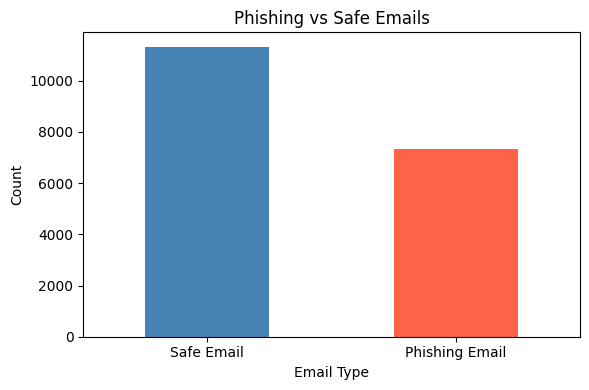


Missing values:
Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64


In [6]:
# CELL 3 — Explore the Data
# How many phishing vs safe emails do we have?
print("Email counts:")
print(df['Email Type'].value_counts())

# Plot it as a bar chart
plt.figure(figsize=(6,4))
df['Email Type'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Phishing vs Safe Emails')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png')  # saves to results later
plt.show()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

In [18]:
# CELL 4 — Lighter Cleaning (keeps more meaning)
import re

def clean_email(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)  # replace URLs with "url"
    text = re.sub(r'<.*?>', ' ', text)                # remove HTML
    text = re.sub(r'[^a-z\s]', ' ', text)             # remove symbols
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    return text

df['clean_text'] = df['Email Text'].apply(clean_email)
print("Cleaning done ✅")
print(df['clean_text'].iloc[3][:200])

Cleaning done ✅
hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet


In [19]:
# CELL 5 — Tokenization with bigger vocabulary
MAX_WORDS = 50000   # increased from 10,000
MAX_LEN = 300       # increased from 200

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded = pad_sequences(sequences, maxlen=MAX_LEN,
                       truncating='post', padding='post')
labels = df['label'].values

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Dataset shape: {padded.shape}")

Vocabulary size: 143066
Dataset shape: (18634, 300)


In [9]:
# CELL 6 — Split Data into Train and Test
# 80% for training, 20% for testing

X_train, X_test, y_train, y_test = train_test_split(
    padded, labels,
    test_size=0.2,      # 20% for testing
    random_state=42     # so results are reproducible
)

print(f"Training emails: {len(X_train)}")
print(f"Testing emails:  {len(X_test)}")

Training emails: 14907
Testing emails:  3727


In [37]:
# CELL 7 — Better Model
from tensorflow.keras.layers import Bidirectional

model = Sequential([
    Embedding(input_dim=50000, output_dim=128),
    Bidirectional(LSTM(64)),  # reads email forwards AND backwards
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# CELL 8 — Retrain
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 92s 820ms/step - accuracy: 0.8590 - loss: 0.3016 - val_accuracy: 0.9510 - val_loss: 0.1384
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 143s 834ms/step - accuracy: 0.9757 - loss: 0.0657 - val_accuracy: 0.9618 - val_loss: 0.0919
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 139s 807ms/step - accuracy: 0.9843 - loss: 0.0361 - val_accuracy: 0.9611 - val_loss: 0.1029
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 143s 813ms/step - accuracy: 0.9862 - loss: 0.0290 - val_accuracy: 0.9631 - val_loss: 0.1073


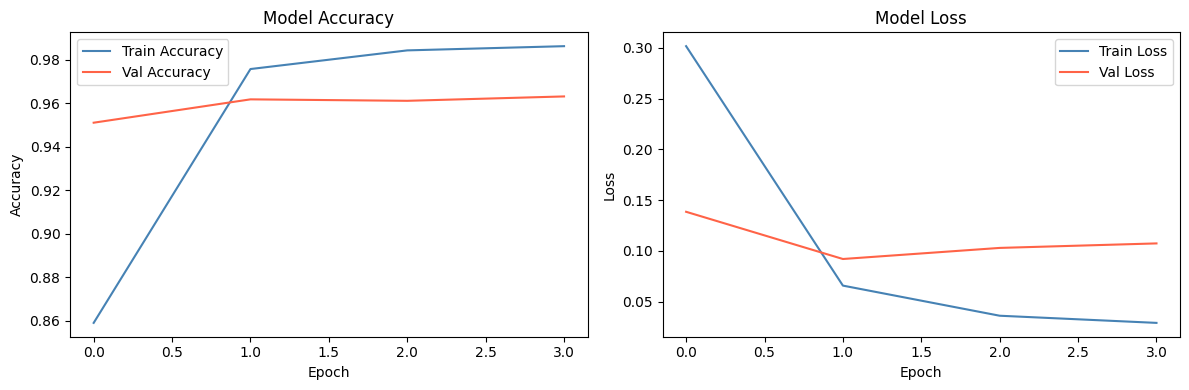

In [39]:
# CELL 9 — Plot Training Accuracy & Loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='tomato')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss', color='steelblue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='tomato')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()

Test Accuracy: 96.99%
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step


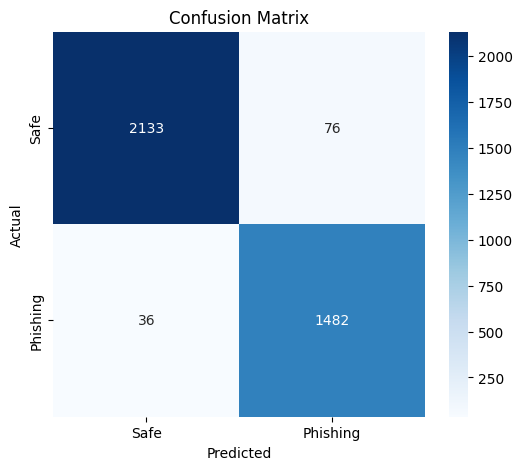


Classification Report:
                precision    recall  f1-score   support

    Safe Email       0.98      0.97      0.97      2209
Phishing Email       0.95      0.98      0.96      1518

      accuracy                           0.97      3727
     macro avg       0.97      0.97      0.97      3727
  weighted avg       0.97      0.97      0.97      3727



In [40]:
# CELL 10 — Evaluate on Test Data
# This is the moment of truth — testing on emails model never saw!

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Phishing'],
            yticklabels=['Safe', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

# Full report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Safe Email', 'Phishing Email']))

In [41]:
# CELL 11 — Save the trained model
model.save('lstm_phishing_model.h5')
print("Model saved ✅")

Model saved ✅


In [46]:
# CELL 12 — Final Demo (using real dataset emails)
def predict_email(email_text, actual_label=None):
    cleaned = clean_email(email_text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded_seq = pad_sequences(seq, maxlen=300, padding='post')
    prediction = model.predict(padded_seq, verbose=0)[0][0]

    if prediction > 0.5:
        label = "🚨 PHISHING DETECTED"
        confidence = prediction
    else:
        label = "✅ SAFE EMAIL"
        confidence = 1 - prediction

    if actual_label:
        print(f"Actual:    {actual_label}")
    print(f"Predicted: {label} ({confidence:.2%} confidence)")
    print(f"Email:     {email_text[:100]}")
    print("-" * 60)

print("=== PHISHING EMAILS ===")
for i in [5, 10, 15]:
    predict_email(df[df['label']==1]['Email Text'].iloc[i], "PHISHING")

print("\n=== SAFE EMAILS ===")
for i in [5, 10, 15]:
    predict_email(df[df['label']==0]['Email Text'].iloc[i], "SAFE")

=== PHISHING EMAILS ===
Actual:    PHISHING
Predicted: ✅ SAFE EMAIL (99.99% confidence)
Email:     formal invite for chase . secrets revealed . how do porn stars perform , stay strong and hard even a
------------------------------------------------------------
Actual:    PHISHING
Predicted: ✅ SAFE EMAIL (99.99% confidence)
Email:     premium adult content looking for high quality adult content at the right price ? then check out xxx
------------------------------------------------------------
Actual:    PHISHING
Predicted: ✅ SAFE EMAIL (99.99% confidence)
Email:     gino , who do u want to win ? the secret on how porn stars grew big dicks ! the answer is here . tur
------------------------------------------------------------

=== SAFE EMAILS ===
Actual:    SAFE
Predicted: ✅ SAFE EMAIL (100.00% confidence)
Email:     re : coastal deal - with exxon participation under the project agreement thanks for the info ! as gr
------------------------------------------------------------
Actual:   